In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = {
    "value" : np.append(np.random.normal(50, 10, 100), [150, 200, 250, 300, 350, 400])
}
df = pd.DataFrame(data)

In [5]:
df

,value
0,63.983904
1,46.917787
2,53.820382
3,53.006463
4,43.440287
...,...
101,200.000000
102,250.000000
103,300.000000
104,350.000000


Text(0.5, 1.0, 'Before Removing Outlier')

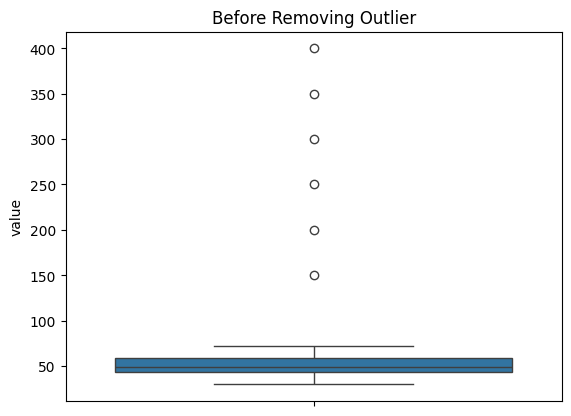

In [6]:
sns.boxplot(y=df['value'])
plt.title("Before Removing Outlier")

### IQR Method

In [7]:
Q1 = df['value'].quantile(0.25) ## 25%
Q3 = df['value'].quantile(0.75) ## 75%
print(f"Q1 : {Q1}, Q3 : {Q3}")

Q1 : 43.76678854527908, Q3 : 58.28697634799343


In [8]:
IQR = Q3 - Q1
IQR

14.520187802714354

In [9]:
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
print(f"lower_bound : {lower_bound}, upper_bound : {upper_bound}")

lower_bound : 21.986506841207547, upper_bound : 80.06725805206496


In [10]:
df['outlier'] = (df['value'] < lower_bound) | (df['value'] > upper_bound)

In [11]:
df

,value,outlier
0,63.983904,False
1,46.917787,False
2,53.820382,False
3,53.006463,False
4,43.440287,False
...,...,...
101,200.000000,True
102,250.000000,True
103,300.000000,True
104,350.000000,True


In [15]:
df_clean = df[df['outlier'] == False]

<Axes: ylabel='value'>

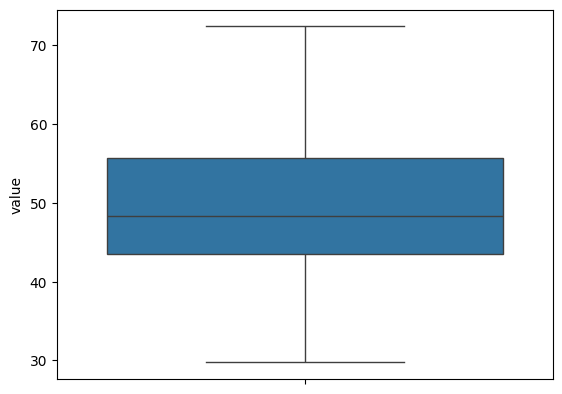

In [16]:
sns.boxplot(df_clean['value'])